In [37]:
#import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit

In [4]:
plt.rcParams['font.size'] = 17

In [5]:
output = pd.read_csv('PBDE_99_daily_projected_2030.csv', 
                     parse_dates=[0], header=0, names=['Date', 'PBDE_99'])
output['year'] = output['Date'].dt.year
discharge = output.groupby('year')['PBDE_99'].mean()

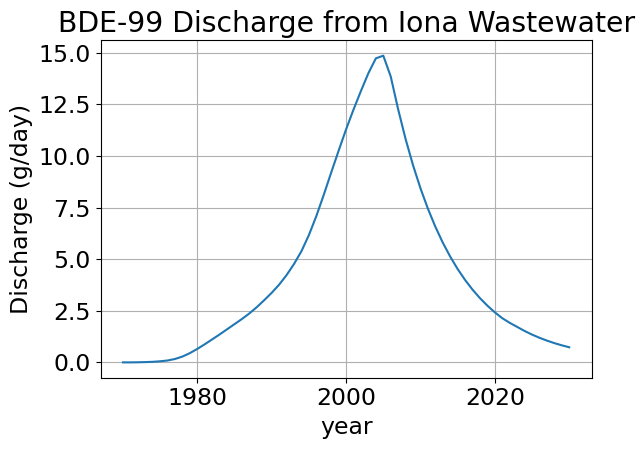

In [6]:
fig, ax = plt.subplots()
discharge.plot(ax=ax)
ax.set_ylabel('Discharge (g/day)')
ax.grid();
ax.set_title('BDE-99 Discharge from Iona Wastewater')
fig.tight_layout()
fig.savefig('pbde99_discharge.png');

# Concentrations near S4-1.5 #

In [9]:
sum_s415 = np.array([381919+552334, 846268+656320, 405950+386180,
                    236621+248517, 174034+182518])
volume = 109.14092697168105 * 10**9 # Volumes.ipynb
time = 61 * 12 # 61 days and 12 outputs per day
print (volume/1e11)

1.0914092697168105


In [10]:
print (discharge[discharge.index == 2018])

year
2018    3.112029
Name: PBDE_99, dtype: float64


In [11]:
# Contribution from 2018
gpp = discharge[discharge.index == 2018].values * 1 / 96 # g/day * day / particle 
gpp # g/particle

array([0.03241696])

In [12]:
sum_s415[0] * gpp / volume / time # g in the volume / volume
# units are g/m3

array([3.79086325e-10])

observations are 50-40 pg/kg 10^-12g/kg or 10^-9 g/m3 but divided by 2 as only 1/2 from Iona

In [13]:
50/2 * 1e-9

2.5000000000000002e-08

In [25]:
nyears = 5
sumit = np.zeros((5))
contrib = np.zeros_like(sumit)
tyears = np.empty_like(sumit)
for iy, year in enumerate(np.arange(2018, 2013, -1)):
    tyears[iy] = year
    contrib[iy] = (discharge[discharge.index == year].values[0] * 1 / 96 * 
                   sum_s415[iy] / volume / time)
    if iy == 0:
        sumit[iy] = contrib[iy]
    else:
        sumit[iy] = sumit[iy-1] + contrib[iy]
    print (tyears[iy], contrib[iy], sumit[iy])
    

2018.0 3.7908632498751743e-10 3.7908632498751743e-10
2017.0 6.905766630976666e-10 1.069662988085184e-09
2016.0 4.124225999068835e-10 1.4820855879920677e-09
2015.0 2.861424027567589e-10 1.7682279907488265e-09
2014.0 2.381980313560092e-10 2.0064260221048356e-09


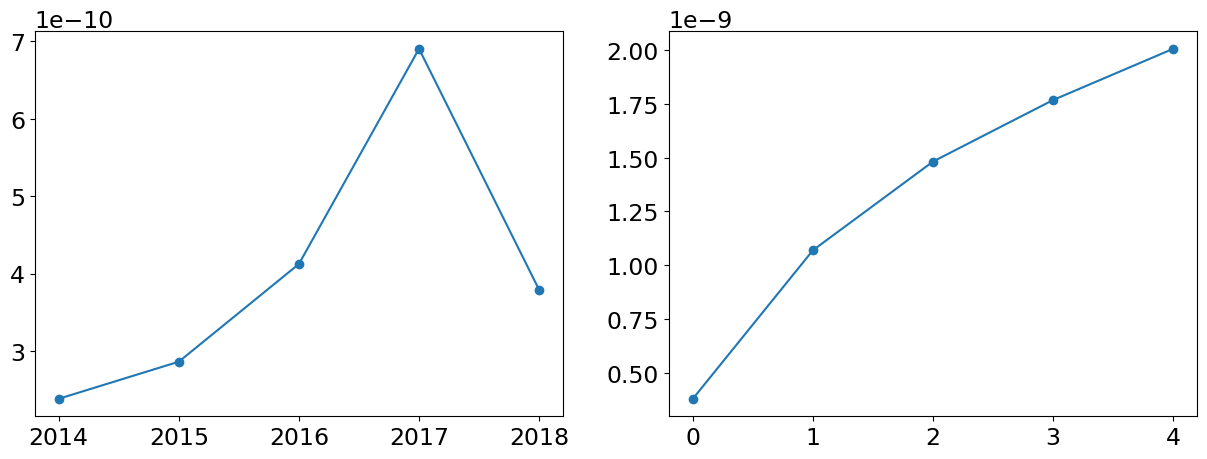

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(tyears, contrib, 'o-')
axs[1].plot(sumit, 'o-');

In [53]:
def curve(t, goal, decay, to):
    return goal * (1. - np.exp(-(t+to)/decay))

In [58]:
popt, pcov = curve_fit(curve, np.arange(nyears-1), sumit[1:], p0=[2e-9, 4, 0.3+1])

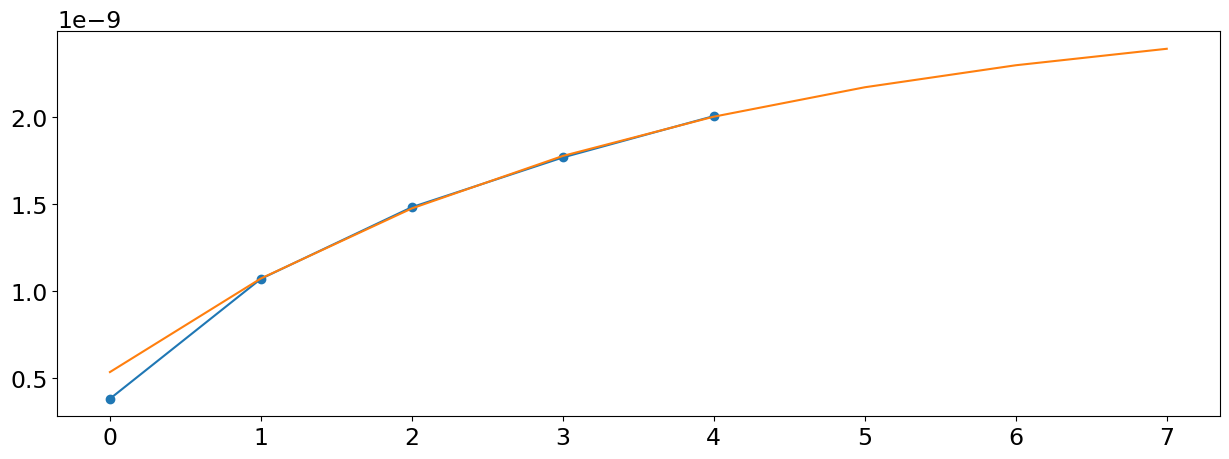

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(sumit, 'o-');
ax.plot(np.arange(0, nyears+3), curve(np.arange(-1,nyears-1+3), popt[0], popt[1], popt[2]));

In [74]:
print (f'Extrapolated concentration {popt[0]:.1e} g/kg')
print (f'Decay time scale {popt[1]:.1f} years')
print (f'Timing shift {popt[2]:.1f} years (expected 1.33)');

Extrapolated concentration 2.7e-09 g/kg
Decay time scale 3.5 years
Timing shift 1.8 years (expected 1.33)
